In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns

# Load data
df = pd.read_excel(r"C:\Users\HP\causal_impact_project\data\raw\Online Retail.xlsx")

# Quick look
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
pip install seaborn



   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [8]:
# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove returns
df = df[df['Quantity'] > 0]

# Remove zero/negative unit price
df = df[df['UnitPrice'] > 0]

# Optional: drop missing CustomerID (~25% loss, but okay for demo)
df = df.dropna(subset=['CustomerID'])

# Create total line price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [9]:
# Convert InvoiceDate to date only
df['Date'] = pd.to_datetime(df['InvoiceDate']).dt.date

# Daily revenue
daily = df.groupby('Date')['TotalPrice'].sum().reset_index()
daily.columns = ['date', 'revenue']

# Sort by date
daily = daily.sort_values('date')

# Set date as datetime index
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.set_index('date').asfreq('D')

# Fill missing dates (weekends/holidays) with 0 revenue? Or forward fill?
# For retail, missing dates = no sales -> 0 is acceptable.
daily['revenue'] = daily['revenue'].fillna(0)

daily.head(10)

,revenue
date,
2010-12-01,46376.49
2010-12-02,47316.53
2010-12-03,23921.71
2010-12-04,0.00
2010-12-05,31771.60
2010-12-06,31215.64
2010-12-07,53795.31
2010-12-08,39248.82
2010-12-09,38231.90


In [10]:
print(f"Start date: {daily.index.min()}")
print(f"End date: {daily.index.max()}")

Start date: 2010-12-01 00:00:00
End date: 2011-12-09 00:00:00


In [11]:
if pd.Timestamp('2011-04-01') in daily.index:
    print("Date exists")
else:
    print("Date missing – we may need to adjust")

Date exists


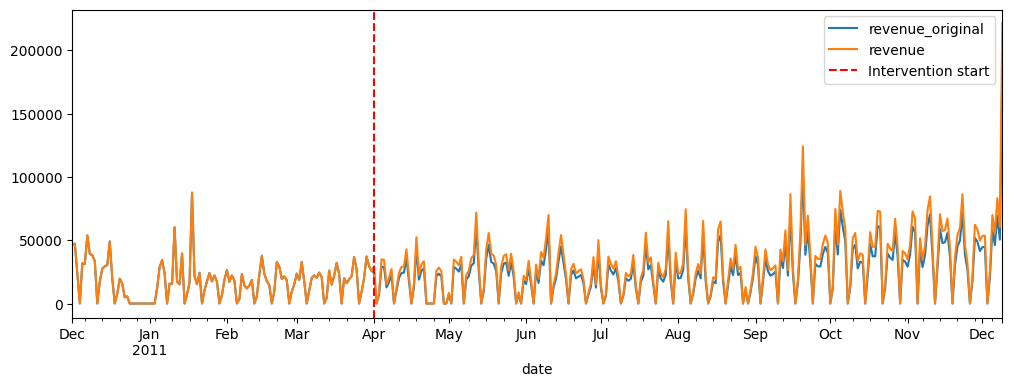

In [12]:
# Copy original revenue to a new column for transparency
daily['revenue_original'] = daily['revenue'].copy()

# Intervention date
intervention_date = pd.Timestamp('2011-04-01')

# Apply synthetic lift
daily['revenue'] = daily['revenue'].where(
    daily.index < intervention_date,
    daily['revenue'] * 1.20   # 20% lift
)

# Check the effect visually
daily[['revenue_original', 'revenue']].plot(figsize=(12,4))
plt.axvline(intervention_date, color='red', linestyle='--', label='Intervention start')
plt.legend()
plt.show()

In [13]:
daily.to_csv('../data/processed/daily_revenue_with_intervention.csv')

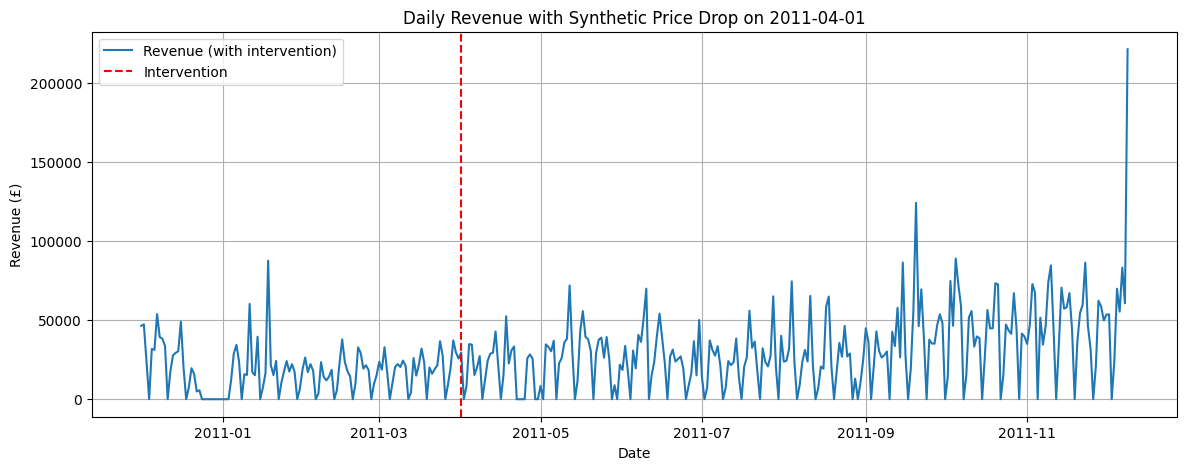

In [14]:
plt.figure(figsize=(14,5))
plt.plot(daily.index, daily['revenue'], label='Revenue (with intervention)')
plt.axvline(intervention_date, color='red', linestyle='--', label='Intervention')
plt.title('Daily Revenue with Synthetic Price Drop on 2011-04-01')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.grid(True)
plt.show()